# 🎓 Day 3: Student Performance Prediction using Decision Tree Classifier
**Bootcamp on Artificial Intelligence - NIELIT Delhi**

In this experiment, we explore **Supervised Machine Learning (Classification)**:
- Load and inspect `student_performance.csv`
- Perform **Exploratory Data Analysis (EDA)** using `groupby` and scatter plots
- Split dataset into **Training (80%)** and **Testing (20%)** sets using `train_test_split`
- Train a **Decision Tree Classifier** (`max_depth=3`)
- Evaluate performance using **Accuracy Score, Confusion Matrix, and Classification Report**
- Visualize the learned decision rules using `plot_tree`
- Predict outcomes for new students

In [14]:
# 1. Environment and Library Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:       ", np.__version__)
print("pandas:      ", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Environment ready!
NumPy:        2.5.3
pandas:       3.0.6
scikit-learn: 1.9.1


In [15]:
# 2. Load Dataset
df = pd.read_csv("student_performance.csv")
df.head()

,student_id,study_hours,attendance,assignments,result
0,1,1.0,58,3,0
1,2,1.5,62,5,0
2,3,2.0,65,6,0
3,4,2.5,68,7,1
4,5,3.0,72,7,1


Average metrics grouped by Result (0 = Fail, 1 = Pass):
        study_hours  attendance  assignments
result                                      
0          1.633333   65.037037     5.296296
1          3.824242   76.060606     8.393939


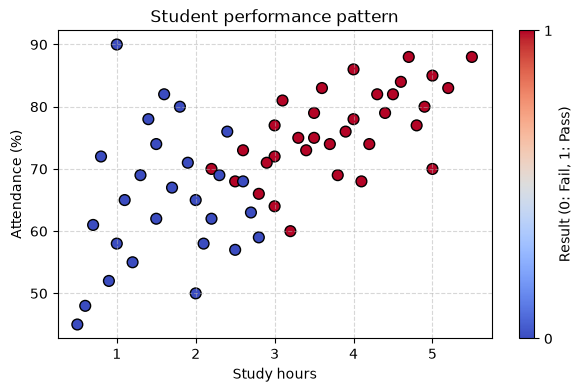

In [16]:
# 3. Exploratory Data Analysis (EDA)
print("Average metrics grouped by Result (0 = Fail, 1 = Pass):")
print(df.groupby("result")[["study_hours", "attendance", "assignments"]].mean())

# Scatter Plot
plt.figure(figsize=(7, 4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"], cmap="coolwarm", edgecolors="k", s=60)
plt.xlabel("Study hours")
plt.ylabel("Attendance (%)")
plt.title("Student performance pattern")
plt.colorbar(label="Result (0: Fail, 1: Pass)", ticks=[0, 1])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [17]:
# 4. Prepare Features (X) and Target (y)
X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60, 3)
y shape: (60,)


In [18]:
# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("\nTraining class distribution:\n", y_train.value_counts())

Training rows: 48
Testing rows : 12

Training class distribution:
 result
1    26
0    22
Name: count, dtype: int64


In [19]:
# 6. Train Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [20]:
# 7. Model Evaluation Metrics
y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Fail (0)", "Pass (1)"]))

Accuracy Score: 100.00%

Confusion Matrix:
 [[5 0]
 [0 7]]

Classification Report:
               precision    recall  f1-score   support

    Fail (0)       1.00      1.00      1.00         5
    Pass (1)       1.00      1.00      1.00         7

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



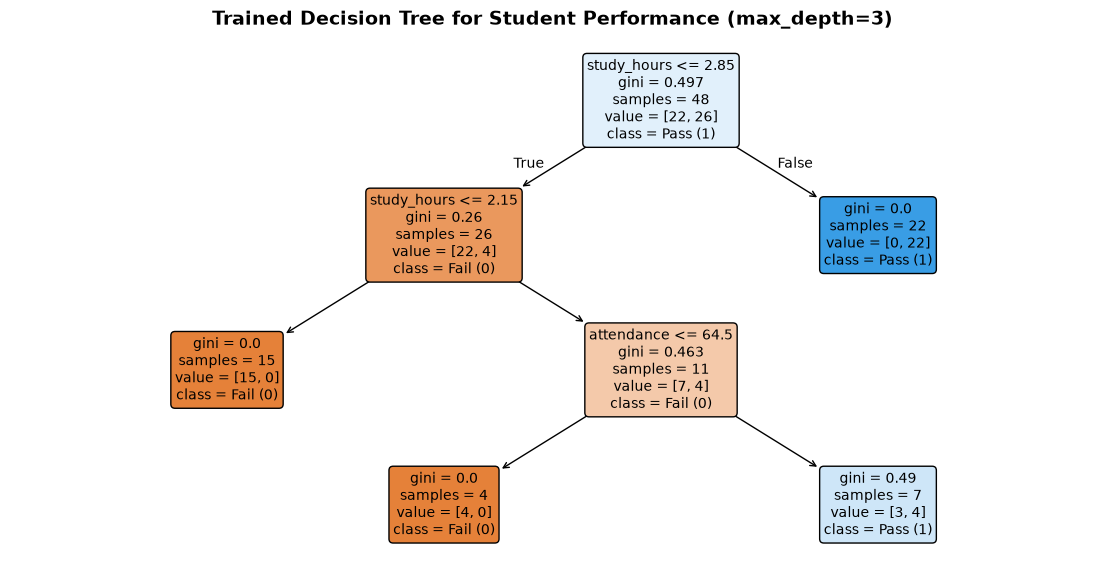

In [21]:
# 8. Visualize the Decision Tree
plt.figure(figsize=(14, 7))
plot_tree(
    model,
    feature_names=["study_hours", "attendance", "assignments"],
    class_names=["Fail (0)", "Pass (1)"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Trained Decision Tree for Student Performance (max_depth=3)", fontsize=14, fontweight="bold")
plt.show()

In [22]:
# 9. Test with New Student Data
sample_students = pd.DataFrame([
    {"Name": "Aarav", "study_hours": 8.0, "attendance": 92, "assignments": 9},
    {"Name": "Sneha", "study_hours": 2.5, "attendance": 62, "assignments": 3},
    {"Name": "Rohan", "study_hours": 5.0, "attendance": 75, "assignments": 6}
])

preds = model.predict(sample_students[["study_hours", "attendance", "assignments"]])
sample_students["Predicted_Result"] = ["Pass" if p == 1 else "Fail" for p in preds]
display(sample_students)

,Name,study_hours,attendance,assignments,Predicted_Result
0,Aarav,8.0,92,9,Pass
1,Sneha,2.5,62,3,Fail
2,Rohan,5.0,75,6,Pass
